--------DAY-2--------

In [1]:
#Import libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import LabelEncoder ,  StandardScaler
from sklearn.model_selection import train_test_split

PROGRAM-1

In [2]:
#Load the Titanic dataset, find and fill missing values
#Loding Dataset
df = sns.load_dataset("titanic")
#Cleaning Data

#Find missing value
miss_val = df.isna().sum()
print("-----Total missing values before cleaning-----")
print(miss_val)

#Fill missing value -- Quantitative by their mean ,categorical by their mode
mode_embarked = df["embarked"].mode()[0]
mode_deck = df["deck"].mode()[0]
mode_embark_town = df["embark_town"].mode()[0]
mean_age = df["age"].mean()
fill_val={"age" : mean_age, "embarked" : mode_embarked, "deck" :mode_deck , "embark_town" : mode_embark_town}
df = df.fillna(value = fill_val , inplace = True)
print("After filling missing value : ")
print(df.isnull().sum())
print("Data After cleaning is : \n" , df.head(2))

-----Total missing values before cleaning-----
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64
After filling missing value : 
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64
Data After cleaning is : 
    survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   

     who  adult_male deck  embark_town alive  alone  
0    man        True    C  Southampton    no  

PROGRAM-2

In [3]:
#Encode 'Sex' and 'Embarked' columns using LabelEncoder in Titanic dataset

# Initialize the label encoder
le_sex = LabelEncoder()
le_embarked = LabelEncoder()

# Fit and transform the text columns into numeric columns
df['sex'] = le_sex.fit_transform(df['sex'])
df['embarked'] = le_embarked.fit_transform(df['embarked'].astype(str))
print("sex and embarked after encoded : ")
print(df[['sex', 'embarked']].head())

sex and embarked after encoded : 
   sex  embarked
0    1         2
1    0         0
2    0         2
3    0         2
4    1         2


PROGRAM-3

In [4]:
#Apply StandardScaler on Age and Fare columns in Titanic Dataset
scaler = StandardScaler()
df[['age', 'fare']] = scaler.fit_transform(df[['age', 'fare']])
print(df[['age', 'fare']].head())

        age      fare
0 -0.592481 -0.502445
1  0.638789  0.786845
2 -0.284663 -0.488854
3  0.407926  0.420730
4  0.407926 -0.486337


PROGRAM-4

In [5]:
#Split dataset 80/20 and verify shapes in Titanic dataset
# Drop non-numeric, redundant, or target columns to isolate features (X)
X = df[['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']]
y = df['survived']

# Perform 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verify the matrix structures
print(f"X_train Shape: {X_train.shape}")
print(f" X_test Shape: {X_test.shape}")
print(f"y_train Shape: {y_train.shape}")
print(f" y_test Shape: {y_test.shape}")

X_train Shape: (712, 7)
 X_test Shape: (179, 7)
y_train Shape: (712,)
 y_test Shape: (179,)


PROGRAM-5

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')
          survived       sex    pclass       age     sibsp     parch  \
survived  1.000000 -0.543351 -0.338481 -0.069809 -0.035322  0.081629   
sex      -0.543351  1.000000  0.131900  0.084153 -0.114631 -0.245489   
pclass   -0.338481  0.131900  1.000000 -0.331339  0.083081  0.018443   
age      -0.069809  0.084153 -0.331339  1.000000 -0.232625 -0.179191   
sibsp    -0.035322 -0.114631  0.083081 -0.232625  1.000000  0.414838   
parch     0.081629 -0.245489  0.018443 -0.179191  0.414838  1.000000   
embarked -0.167675  0.108262  0.162098 -0.026749  0.068230  0.039798   
fare      0.257307 -0.182333 -0.549500  0.091566  0.159651  0.216225   

          embarked      fare  
survived -0.167675  0.257307  
sex       0.108262 -0.182333  
pclass    0.162098 -0.549500  
age      -0.026749  0.091566  
sibsp     

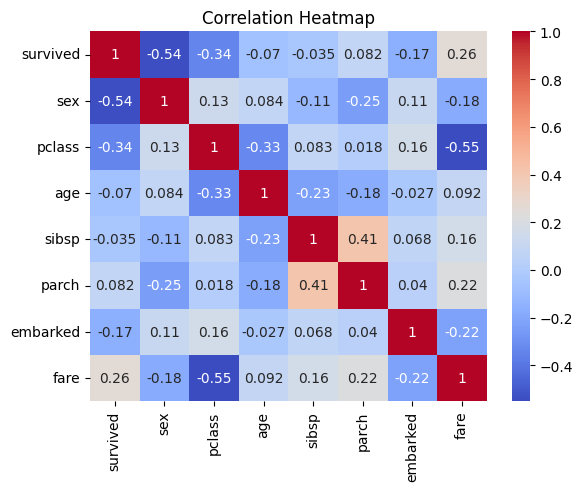


Top 5 features strongly correlated with Survival:
 ['survived', 'sex', 'pclass', 'fare', 'embarked', 'parch']


In [6]:
#Create a correlation heatmap and identify top 5 features in Titanic dataset
print(df.columns)
numeric_df = df.select_dtypes(include=['float64', 'int64', 'int32'])

df_mat =numeric_df[['survived' , 'sex' , 'pclass', 'age', 'sibsp', 'parch', 'embarked' , 'fare']]
corr_matrix = df_mat.corr()
print(corr_matrix)
fig = plt.figure()
sns.heatmap(corr_matrix ,annot = True , cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()
fig.savefig("P5Heatmap plot.png")
top_5_features = corr_matrix['survived'].abs().sort_values(ascending=False).index[0:6]
print("\nTop 5 features strongly correlated with Survival:\n", list(top_5_features))